<a href="https://colab.research.google.com/github/festusadjetey118-cpu/Projects/blob/main/stroke_detection_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="display: flex;
            align-items: center;
            justify-content: center;
            padding: 20px 30px;
            margin: 30px auto;
            max-width: 1000px;
            border-radius: 20px;
            background: linear-gradient(135deg, #003366 0%, #006699 50%, #00cccc 100%);
            color: #ffffff;
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            box-shadow: 0 4px 20px rgba(0,0,0,0.2);">
  
  <img src="https://i.vimeocdn.com/video/663892561-e13235b351d37090718f37942a5c40903728212d86e47584f2a7a812764d5667-d?mw=1920&mh=1080&q=70"
       alt="Brain Illustration"
       style="width:120px; height:auto; border-radius:12px; margin-right:25px; box-shadow: 0 2px 10px rgba(0,0,0,0.3);">

  <div style="text-align: left;">
    <div style="font-size: 1.7rem; font-weight: 600;">
      Deep Learning Model for Stroke Classification
    </div>
    <div style="font-size: 1.1rem; font-weight: 300; color: #e0f7fa;">
      A Comparative Analysis
    </div>
  </div>
</div>


In [ ]:
from google.colab import drive

In [ ]:
drive.mount ('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf

print(np.__version__)
print(pd.__version__)
print(tf.__version__)

2.0.2
2.2.2
2.18.0


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC, Precision, Recall
import matplotlib.pyplot as plt
import cv2
import os
import datetime
import time

# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Data paths
train_dir = '/content/drive/MyDrive/Brain_Stroke_CT-SCAN_image/Train'
test_dir = '/content/drive/MyDrive/Brain_Stroke_CT-SCAN_image/Test'
val_dir = '/content/drive/MyDrive/Brain_Stroke_CT-SCAN_image/Validation'

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50
AUTOTUNE = tf.data.AUTOTUNE

# Load datasets
train_ds = image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

val_ds = image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

test_ds = image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

# Data augmentation
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
])

# Preprocessing function
preprocess_input = tf.keras.applications.densenet.preprocess_input

# Base model
base_model = DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # Freeze for feature extraction

# Build model
inputs = Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation='sigmoid')(x)
model = Model(inputs, outputs)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc')]
)

# Callbacks
log_dir = os.path.join("logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
callbacks = [
    EarlyStopping(patience=5, monitor='val_loss', restore_best_weights=True),
    ModelCheckpoint('densenet121_stroke_best_model.h5', save_best_only=True, monitor='val_accuracy', mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6),
    TensorBoard(log_dir=log_dir)
]

# Train the model
print("Starting initial training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# Fine-tuning
print("\nStarting fine-tuning...")
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc')]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# Fixed Grad-CAM Implementation
def get_gradcam_heatmap(img_array, model, last_conv_layer_name):
    """Generate Grad-CAM heatmap for the given image."""
    # Find the base model (DenseNet121)
    base_model = None
    for layer in model.layers:
        if hasattr(layer, 'name') and 'densenet121' in layer.name:
            base_model = layer
            break

    if base_model is None:
        raise ValueError("Could not find DenseNet121 base model")

    # Apply preprocessing to the input image
    preprocess_input = tf.keras.applications.densenet.preprocess_input
    preprocessed_img = preprocess_input(img_array)

    # Create a simplified model that goes from preprocessed input to conv layer output and final prediction
    # We'll manually trace through the model layers
    with tf.GradientTape() as tape:
        tape.watch(preprocessed_img)

        # Pass through base model to get conv layer output
        conv_output = base_model(preprocessed_img, training=False)

        # Get the specific conv layer output we want
        conv_layer_model = tf.keras.Model(
            inputs=base_model.input,
            outputs=base_model.get_layer(last_conv_layer_name).output
        )
        last_conv_layer_output = conv_layer_model(preprocessed_img, training=False)

        # Continue through the rest of the model (GAP, Dense layers)
        x = tf.keras.layers.GlobalAveragePooling2D()(conv_output)
        x = tf.keras.layers.Dropout(0.5)(x, training=False)
        x = tf.keras.layers.Dense(128, activation='relu')(x)
        x = tf.keras.layers.Dropout(0.3)(x, training=False)
        preds = tf.keras.layers.Dense(1, activation='sigmoid')(x)

        # Use the prediction for the positive class (stroke)
        class_channel = preds[:, 0]

    # Get gradients of the class output with respect to the conv layer output
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # Pool the gradients across the spatial dimensions
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the conv layer output by the gradients
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize the heatmap
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy(), preds.numpy()[0][0]

def display_gradcam(model, dataset, last_conv_layer_name, class_names, num_samples=5):
    """Display original images alongside their Grad-CAM visualizations."""
    plt.figure(figsize=(20, 10))

    sample_count = 0
    for images, labels in dataset.take(1):
        for i in range(min(num_samples, len(images))):
            # Prepare image
            img = images[i].numpy()
            # Normalize image to 0-1 range for display
            img_display = (img - img.min()) / (img.max() - img.min())
            img_array = tf.expand_dims(images[i], axis=0)

            # Generate heatmap
            try:
                heatmap, prediction = get_gradcam_heatmap(img_array, model, last_conv_layer_name)

                # Rescale heatmap to 0-255 and convert to proper size
                heatmap = np.uint8(255 * heatmap)
                heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

                # Create jet colormap
                jet = plt.colormaps.get_cmap("jet")
                jet_colors = jet(np.arange(256))[:, :3]
                jet_heatmap = jet_colors[heatmap]

                # Superimpose heatmap on original image
                superimposed_img = jet_heatmap * 0.4 + img_display * 0.6
                superimposed_img = np.clip(superimposed_img, 0, 1)

                # Determine predicted class and confidence
                pred_class = class_names[1] if prediction > 0.5 else class_names[0]  # 1=Stroke, 0=Normal
                confidence = prediction if prediction > 0.5 else 1 - prediction
                true_class = class_names[int(labels[i])]

                # Display original image
                plt.subplot(2, num_samples, i+1)
                plt.imshow(img_display)
                plt.title(f"True: {true_class}\nOriginal Image", fontsize=10)
                plt.axis('off')

                # Display Grad-CAM
                plt.subplot(2, num_samples, num_samples+i+1)
                plt.imshow(superimposed_img)
                plt.title(f"Pred: {pred_class}\nConfidence: {confidence:.3f}", fontsize=10)
                plt.axis('off')

                sample_count += 1

            except Exception as e:
                print(f"Error generating Grad-CAM for sample {i}: {str(e)}")
                # Still display the original image even if Grad-CAM fails
                plt.subplot(2, num_samples, i+1)
                plt.imshow(img_display)
                plt.title(f"True: {class_names[int(labels[i])]}\nOriginal Image", fontsize=10)
                plt.axis('off')

                plt.subplot(2, num_samples, num_samples+i+1)
                plt.imshow(img_display)
                plt.title("Grad-CAM Failed", fontsize=10)
                plt.axis('off')
                continue

        plt.tight_layout()
        plt.show()
        break

def find_last_conv_layer(model):
    """Find the last convolutional layer in the DenseNet121 base model."""
    base_model = None
    for layer in model.layers:
        if hasattr(layer, 'name') and 'densenet121' in layer.name:
            base_model = layer
            break

    if base_model is None:
        raise ValueError("Could not find DenseNet121 base model")

    # Look for the last convolutional layer
    last_conv_layer_name = None
    for layer in reversed(base_model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer_name = layer.name
            break

    return last_conv_layer_name

# Model evaluation
def evaluate_model(model, test_ds):
    """Evaluate the model on test dataset."""
    print("\nEvaluating model on test set...")
    results = model.evaluate(test_ds, verbose=1)

    metric_names = ['loss', 'accuracy', 'precision', 'recall', 'auc']
    print("\nTest Evaluation Metrics:")
    for i, metric_name in enumerate(metric_names):
        if metric_name == 'loss':
            print(f"{metric_name.capitalize()}: {results[i]:.4f}")
        else:
            print(f"{metric_name.capitalize()}: {results[i]*100:.2f}%")

    return results

# Get class names
class_names = train_ds.class_names
print(f"Class names: {class_names}")

# Find the last convolutional layer
try:
    last_conv_layer_name = find_last_conv_layer(model)
    print(f"Using layer: {last_conv_layer_name} for Grad-CAM")

    # Display Grad-CAM visualization
    print("\nGenerating Grad-CAM visualizations...")
    display_gradcam(
        model=model,
        dataset=val_ds,
        last_conv_layer_name=last_conv_layer_name,
        class_names=class_names,
        num_samples=5
    )

except Exception as e:
    print(f"Error with Grad-CAM visualization: {str(e)}")
    print("Continuing with model evaluation...")

# Evaluate the model
evaluate_model(model, test_ds)

# Optional: Plot training history
def plot_training_history(history, history_fine=None):
    """Plot training and validation metrics."""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Combine histories if fine-tuning was performed
    if history_fine is not None:
        # Combine metrics
        combined_history = {}
        for key in history.history.keys():
            combined_history[key] = history.history[key] + history_fine.history[key]
    else:
        combined_history = history.history

    # Plot accuracy
    axes[0, 0].plot(combined_history['accuracy'], label='Training Accuracy')
    axes[0, 0].plot(combined_history['val_accuracy'], label='Validation Accuracy')
    axes[0, 0].set_title('Model Accuracy')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # Plot loss
    axes[0, 1].plot(combined_history['loss'], label='Training Loss')
    axes[0, 1].plot(combined_history['val_loss'], label='Validation Loss')
    axes[0, 1].set_title('Model Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # Plot AUC
    axes[1, 0].plot(combined_history['auc'], label='Training AUC')
    axes[1, 0].plot(combined_history['val_auc'], label='Validation AUC')
    axes[1, 0].set_title('Model AUC')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('AUC')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    # Plot Precision and Recall
    axes[1, 1].plot(combined_history['precision'], label='Training Precision')
    axes[1, 1].plot(combined_history['val_precision'], label='Validation Precision')
    axes[1, 1].plot(combined_history['recall'], label='Training Recall')
    axes[1, 1].plot(combined_history['val_recall'], label='Validation Recall')
    axes[1, 1].set_title('Precision and Recall')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

# Plot training history
print("\nPlotting training history...")
plot_training_history(history, history_fine)

Found 1850 files belonging to 2 classes.
Found 351 files belonging to 2 classes.
Found 127 files belonging to 2 classes.
Starting initial training...
Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.5374 - auc: 0.5411 - loss: 0.8767 - precision: 0.5632 - recall: 0.5517

58/58 ━━━━━━━━━━━━━━━━━━━━ 42s 378ms/step - accuracy: 0.5378 - auc: 0.5418 - loss: 0.8755 - precision: 0.5634 - recall: 0.5525 - val_accuracy: 0.7407 - val_auc: 0.8066 - val_loss: 0.5725 - val_precision: 0.7486 - val_recall: 0.7444 - learning_rate: 1.0000e-04
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.6116 - auc: 0.6510 - loss: 0.7215 - precision: 0.6416 - recall: 0.6216

58/58 ━━━━━━━━━━━━━━━━━━━━ 30s 283ms/step - accuracy: 0.6116 - auc: 0.6512 - loss: 0.7213 - precision: 0.6412 - recall: 0.6220 - val_accuracy: 0.7920 - val_auc: 0.8631 - val_loss: 0.5142 - val_precision: 0.8129 - val_recall: 0.7722 - learning_rate: 1.0000e-04
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 20s 273ms/step - accuracy: 0.6737 - auc: 0.7246 - loss: 0.6361 - precision: 0.7052 - recall: 0.6637 - val_accuracy: 0.7920 - val_auc: 0.8808 - val_loss: 0.4857 - val_precision: 0.7688 - val_recall: 0.8500 - learning_rate: 1.0000e-04
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.6716 - auc: 0.7444 - loss: 0.6189 - precision: 0.6758 - recall: 0.6979

58/58 ━━━━━━━━━━━━━━━━━━━━ 17s 296ms/step - accuracy: 0.6718 - auc: 0.7445 - loss: 0.6189 - precision: 0.6760 - recall: 0.6980 - val_accuracy: 0.8063 - val_auc: 0.8899 - val_loss: 0.4683 - val_precision: 0.7947 - val_recall: 0.8389 - learning_rate: 1.0000e-04
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.7128 - auc: 0.7724 - loss: 0.5829 - precision: 0.7342 - recall: 0.7029

58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 336ms/step - accuracy: 0.7126 - auc: 0.7723 - loss: 0.5830 - precision: 0.7337 - recall: 0.7033 - val_accuracy: 0.8205 - val_auc: 0.8974 - val_loss: 0.4572 - val_precision: 0.8162 - val_recall: 0.8389 - learning_rate: 1.0000e-04
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.6956 - auc: 0.7483 - loss: 0.6084 - precision: 0.7379 - recall: 0.6426

...

58/58 ━━━━━━━━━━━━━━━━━━━━ 16s 281ms/step - accuracy: 0.7376 - auc: 0.8110 - loss: 0.5345 - precision: 0.7632 - recall: 0.7270 - val_accuracy: 0.8547 - val_auc: 0.9244 - val_loss: 0.4152 - val_precision: 0.8817 - val_recall: 0.8278 - learning_rate: 1.0000e-04
Epoch 12/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 300ms/step - accuracy: 0.7519 - auc: 0.8302 - loss: 0.5058 - precision: 0.7704 - recall: 0.7580 - val_accuracy: 0.8405 - val_auc: 0.9256 - val_loss: 0.4114 - val_precision: 0.8735 - val_recall: 0.8056 - learning_rate: 1.0000e-04
Epoch 13/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 16s 268ms/step - accuracy: 0.7426 - auc: 0.8269 - loss: 0.5097 - precision: 0.7690 - recall: 0.7366 - val_accuracy: 0.8433 - val_auc: 0.9272 - val_loss: 0.4087 - val_precision: 0.8743 - val_recall: 0.8111 - learning_rate: 1.0000e-04
Epoch 14/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.7444 - auc: 0.8158 - loss: 0.5330 - precision: 0.7850 - recall: 0.7128

58/58 ━━━━━━━━━━━━━━━━━━━━ 23s 319ms/step - accuracy: 0.7445 - auc: 0.8160 - loss: 0.5327 - precision: 0.7848 - recall: 0.7133 - val_accuracy: 0.8661 - val_auc: 0.9285 - val_loss: 0.4090 - val_precision: 0.8634 - val_recall: 0.8778 - learning_rate: 1.0000e-04
Epoch 15/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 16s 279ms/step - accuracy: 0.7534 - auc: 0.8328 - loss: 0.5043 - precision: 0.7775 - recall: 0.7604 - val_accuracy: 0.8519 - val_auc: 0.9303 - val_loss: 0.4048 - val_precision: 0.8765 - val_recall: 0.8278 - learning_rate: 1.0000e-04
Epoch 16/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 15s 263ms/step - accuracy: 0.7644 - auc: 0.8399 - loss: 0.4908 - precision: 0.7865 - recall: 0.7490 - val_accuracy: 0.8575 - val_auc: 0.9309 - val_loss: 0.4069 - val_precision: 0.8824 - val_recall: 0.8333 - learning_rate: 1.0000e-04
Epoch 17/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 21s 275ms/step - accuracy: 0.7563 - auc: 0.8378 - loss: 0.4985 - precision: 0.7875 - recall: 0.7392 - val_accuracy: 0.8632 - val_auc: 0.9323 - val_loss: 0.40

58/58 ━━━━━━━━━━━━━━━━━━━━ 22s 305ms/step - accuracy: 0.7837 - auc: 0.8684 - loss: 0.4497 - precision: 0.7959 - recall: 0.7983 - val_accuracy: 0.8689 - val_auc: 0.9383 - val_loss: 0.3770 - val_precision: 0.8681 - val_recall: 0.8778 - learning_rate: 1.0000e-04
Epoch 31/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.7705 - auc: 0.8599 - loss: 0.4680 - precision: 0.8113 - recall: 0.7516

58/58 ━━━━━━━━━━━━━━━━━━━━ 21s 309ms/step - accuracy: 0.7706 - auc: 0.8598 - loss: 0.4681 - precision: 0.8110 - recall: 0.7518 - val_accuracy: 0.8718 - val_auc: 0.9395 - val_loss: 0.3791 - val_precision: 0.8771 - val_recall: 0.8722 - learning_rate: 1.0000e-04
Epoch 32/50
25/58 ━━━━━━━━━━━━━━━━━━━━ 7s 237ms/step - accuracy: 0.7765 - auc: 0.8689 - loss: 0.4531 - precision: 0.8024 - recall: 0.7755

KeyboardInterrupt: 

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard, Callback
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC, Precision, Recall
import matplotlib.pyplot as plt
import cv2
import os
import datetime
import time

# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Data paths
train_dir = '/content/drive/MyDrive/Brain_Stroke_CT-SCAN_image/Train'
test_dir = '/content/drive/MyDrive/Brain_Stroke_CT-SCAN_image/Test'
val_dir = '/content/drive/MyDrive/Brain_Stroke_CT-SCAN_image/Validation'

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50
AUTOTUNE = tf.data.AUTOTUNE

# Load datasets
train_ds = image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

val_ds = image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

test_ds = image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

# Data augmentation
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
])

# Preprocessing function
preprocess_input = tf.keras.applications.densenet.preprocess_input

# Base model
base_model = DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3),
    name="densenet121" # Added name for easier access
)
base_model.trainable = False  # Freeze for feature extraction

# Build model
inputs = Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation='sigmoid')(x)
model = Model(inputs, outputs)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc')]
)

# Callbacks
log_dir = os.path.join("logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
callbacks = [
    EarlyStopping(patience=5, monitor='val_loss', restore_best_weights=True),
ModelCheckpoint('densenet121_stroke_best_model_GRADCAM.keras', save_best_only=True, monitor='val_accuracy', mode='max')    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6),
    TensorBoard(log_dir=log_dir)
]

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# Fine-tuning
base_model.trainable = True
fine_tune_at = 100  # Unfreeze last layers
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc')]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# Grad-CAM Implementation
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Get the base model layer
    base_model = model.get_layer("densenet121")
    # Get the last convolutional layer from the base model
    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    # Create a model that maps the input image to the activations of the last conv layer as well as the model predictions
    grad_model = tf.keras.models.Model(
        inputs=model.inputs, # Corrected to use the main model's inputs
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(model, dataset, last_conv_layer_name, class_names, num_samples=5):
    plt.figure(figsize=(20, 10))
    for images, labels in dataset.take(1):  # Take one batch
        for i in range(min(num_samples, len(images))):
            img_array = tf.expand_dims(images[i], axis=0)

            # Generate heatmap
            heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

            # Rescale heatmap to 0-255
            heatmap = np.uint8(255 * heatmap)

            # Use jet colormap
            jet = plt.colormaps.get_cmap("jet")
            jet_colors = jet(np.arange(256))[:, :3]
            jet_heatmap = jet_colors[heatmap]

            # Create superimposed image
            img = images[i].numpy()
            img = (img - img.min()) / (img.max() - img.min())  # Normalize to 0-1

            jet_heatmap = cv2.resize(jet_heatmap, (img.shape[1], img.shape[0]))
            superimposed_img = jet_heatmap * 0.4 + img * 0.6
            superimposed_img = (superimposed_img / superimposed_img.max()) * 255

            # Get predictions
            pred = model.predict(img_array)
            pred_class = class_names[int(pred[0][0] > 0.5)]
            true_class = class_names[int(labels[i])]

            # Display original
            plt.subplot(2, num_samples, i+1)
            plt.imshow(img)
            plt.title(f"True: {true_class}\nOriginal")
            plt.axis('off')

            # Display Grad-CAM
            plt.subplot(2, num_samples, num_samples+i+1)
            plt.imshow(superimposed_img.astype('uint8'))
            plt.title(f"Pred: {pred_class}\n({pred[0][0]:.2f})")
            plt.axis('off')

        plt.tight_layout()
        plt.show()
        break

# Get class names
class_names = train_ds.class_names

# Display Grad-CAM visualization
display_gradcam(
    model=model,
    dataset=val_ds,
    last_conv_layer_name="conv5_block16_2_conv",  # Last conv layer in DenseNet121
    class_names=class_names,
    num_samples=5
)

# Model evaluation
def evaluate_model(model, test_ds):
    results = model.evaluate(test_ds)
    print("\nTest Evaluation:")
    print(f"Loss: {results[0]:.4f}")
    print(f"Accuracy: {results[1]*100:.2f}%")
    print(f"Precision: {results[2]*100:.2f}%")
    print(f"Recall: {results[3]*100:.2f}%")
    print(f"AUC: {results[4]*100:.2f}%")

evaluate_model(model, test_ds)

Using layer: conv5_block16_2_conv for Grad-CAM


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_1311']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


KeyError: 'Exception encountered when calling Functional.call().\n\n\x1b[1m137865148661072\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(1, 224, 224, 3), dtype=float32)\n  • training=None\n  • mask=None'

<Figure size 2000x1000 with 0 Axes>

In [ ]:
# TensorFlow & Keras
from tensorflow.keras.applications import DenseNet121, ResNet50, Xception
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard, Callback
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC, Precision, Recall

# Scikit-learn for evaluation
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# Standard libraries
import os
import datetime
import matplotlib.pyplot as plt
import itertools
import time

print ('modules loaded')

modules loaded


In [ ]:
# Set seeds for reproducibility
tf.random.set_seed(42)

In [ ]:
# Data paths
train_dir =  r'/content/drive/MyDrive/Brain_Stroke_CT-SCAN_image/Train'
test_dir = r'/content/drive/MyDrive/Brain_Stroke_CT-SCAN_image/Test'
val_dir = r'/content/drive/MyDrive/Brain_Stroke_CT-SCAN_image/Validation'

In [ ]:
# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
# Load datasets
train_ds = image_dataset_from_directory(train_dir,
                                        image_size=IMG_SIZE,
                                        batch_size=BATCH_SIZE,
                                        label_mode="binary")

val_ds = image_dataset_from_directory(val_dir,
                                      image_size=IMG_SIZE,
                                      batch_size=BATCH_SIZE,
                                      label_mode="binary")

test_ds = image_dataset_from_directory(test_dir,
                                       image_size=IMG_SIZE,
                                       batch_size=BATCH_SIZE,
                                       label_mode="binary")

Found 1850 files belonging to 2 classes.
Found 351 files belonging to 2 classes.
Found 127 files belonging to 2 classes.


In [ ]:
def plot_training(hist):
    tr_acc = hist.history['accuracy']
    tr_loss = hist.history['loss']
    val_acc = hist.history['val_accuracy']
    val_loss = hist.history['val_loss']

    index_loss = np.argmin(val_loss)
    val_lowest = val_loss[index_loss]
    index_acc = np.argmax(val_acc)
    acc_highest = val_acc[index_acc]

    plt.figure(figsize=(20, 8))
    plt.style.use('fivethirtyeight')
    Epochs = [i + 1 for i in range(len(tr_acc))]

    plt.subplot(1, 2, 1)
    plt.plot(Epochs, tr_loss, 'r', label='Training loss')
    plt.plot(Epochs, val_loss, 'g', label='Validation loss')
    plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=f'Best epoch = {index_loss + 1}')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(Epochs, tr_acc, 'r', label='Training Accuracy')
    plt.plot(Epochs, val_acc, 'g', label='Validation Accuracy')
    plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=f'Best epoch = {index_acc + 1}')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()


In [ ]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], '.2f') if normalize else str(cm[i, j]),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:5px; color:white; margin:0; font-size:100%; font-family:Pacifico; background-color:#28a745; overflow:hidden"><b> Data Preprocessing 📊 </b></div>

In [ ]:
# === PREFETCH & CACHE ===
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# === DATA AUGMENTATION ===
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),  # ok: left-right symmetry
    tf.keras.layers.RandomRotation(0.05),      # small rotations
    tf.keras.layers.RandomZoom(0.05),          # small zoom-in/out
    tf.keras.layers.RandomContrast(0.05),      # slight contrast
    tf.keras.layers.RandomTranslation(0.05, 0.05),  # slight shift
])



<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:5px; color:white; margin:0; font-size:100%; font-family:Pacifico; background-color:#28a745; overflow:hidden"><b> Build Model 🎯 </b></div>

## DenseNet121 Model

In [ ]:
# === PREPROCESSING FUNCTION ===
preprocess_input = tf.keras.applications.densenet.preprocess_input


In [ ]:
# === BASE MODEL ===
base_model1 = DenseNet121(include_top=False,
                         weights='imagenet',
                         input_shape=(224, 224, 3))
base_model1.trainable = False  # Freeze for feature extraction

# === BUILD MODEL ===
inputs1 = Input(shape=(224, 224, 3))
x = data_augmentation(inputs1)
x = preprocess_input(x)
x = base_model1(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs1 = Dense(1, activation='sigmoid')(x)
model1 = Model(inputs1, outputs1)

# === COMPILE MODEL ===
model1.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc')])

# Custom Callback to track validation accuracy improvement
class ValAccuracyImprovement(Callback):
    def __init__(self):
        super().__init__()
        self.best_val_accuracy = 0.0

    def on_epoch_end(self, epoch, logs=None):
        current_val_accuracy = logs.get('val_accuracy', 0.0)

        if current_val_accuracy > self.best_val_accuracy:
            print(f"\n Validation accuracy improved from {self.best_val_accuracy:.4f} to {current_val_accuracy:.4f}")
            self.best_val_accuracy = current_val_accuracy
        else:
            print(f"\n Validation accuracy did not improve (Best: {self.best_val_accuracy:.4f}, Current: {current_val_accuracy:.4f})")

val_accuracy_cb1 = ValAccuracyImprovement()  # Custom callback

# === CALLBACKS ===
log_dir = os.path.join("logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
callbacks = [
    EarlyStopping(patience=5, monitor='val_loss', restore_best_weights=True),
    ModelCheckpoint('densenet121_stroke_best_model.h5', save_best_only=True, monitor='val_accuracy', mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6),
    TensorBoard(log_dir=log_dir),
    val_accuracy_cb1

]
training_start_time1 = time.time()

# === TRAIN PHASE 1: Feature Extraction ===

history1 = model1.fit(train_ds,
                    validation_data=val_ds,
                    epochs=EPOCHS,
                    callbacks=callbacks)

# === UNFREEZE AND FINE-TUNE ===
base_model1.trainable = True
fine_tune_at = 100  # Unfreeze last 50 layers
for layer in base_model1.layers[:fine_tune_at]:
    layer.trainable = False

# Recompile
model1.compile(optimizer=Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc')])

# === TRAIN PHASE 2: Fine-tuning ===
history_fine1 = model1.fit(train_ds,
                         validation_data=val_ds,
                         epochs=EPOCHS,
                         callbacks=callbacks)

training_end_time1 = time.time()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.5267 - auc: 0.5365 - loss: 0.8637 - precision: 0.5448 - recall: 0.5373


 Validation accuracy improved from 0.0000 to 0.6923
58/58 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.5270 - auc: 0.5370 - loss: 0.8631 - precision: 0.5451 - recall: 0.5378 - val_accuracy: 0.6923 - val_auc: 0.8185 - val_loss: 0.5732 - val_precision: 0.6488 - val_recall: 0.8722 - learning_rate: 1.0000e-04
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.5955 - auc: 0.6397 - loss: 0.7222 - precision: 0.6026 - recall: 0.6570


 Validation accuracy improved from 0.6923 to 0.7692
58/58 ━━━━━━━━━━━━━━━━━━━━ 12s 205ms/step - accuracy: 0.5958 - auc: 0.6401 - loss: 0.7218 - precision: 0.6029 - recall: 0.6570 - val_accuracy: 0.7692 - val_auc: 0.8564 - val_loss: 0.5230 - val_precision: 0.7302 - val_recall: 0.8722 - learning_rate: 1.0000e-04
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.6667 - auc: 0.7316 - loss: 0.6221 - precision: 0.6716 - recall: 0.7108


 Validation accuracy improved from 0.7692 to 0.7721
58/58 ━━━━━━━━━━━━━━━━━━━━ 12s 209ms/step - accuracy: 0.6668 - auc: 0.7316 - loss: 0.6222 - precision: 0.6718 - recall: 0.7106 - val_accuracy: 0.7721 - val_auc: 0.8704 - val_loss: 0.5093 - val_precision: 0.7315 - val_recall: 0.8778 - learning_rate: 1.0000e-04
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.6951 - auc: 0.7610 - loss: 0.5952 - precision: 0.7007 - recall: 0.7463


 Validation accuracy improved from 0.7721 to 0.8034
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 188ms/step - accuracy: 0.6948 - auc: 0.7609 - loss: 0.5954 - precision: 0.7004 - recall: 0.7458 - val_accuracy: 0.8034 - val_auc: 0.8814 - val_loss: 0.4817 - val_precision: 0.7789 - val_recall: 0.8611 - learning_rate: 1.0000e-04
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.6951 - auc: 0.7638 - loss: 0.5908 - precision: 0.7180 - recall: 0.6853

...


 Validation accuracy improved from 0.9601 to 0.9630
58/58 ━━━━━━━━━━━━━━━━━━━━ 26s 442ms/step - accuracy: 0.9526 - auc: 0.9908 - loss: 0.1275 - precision: 0.9651 - recall: 0.9459 - val_accuracy: 0.9630 - val_auc: 0.9906 - val_loss: 0.1166 - val_precision: 0.9718 - val_recall: 0.9556 - learning_rate: 1.0000e-05
Epoch 13/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.9558 - auc: 0.9899 - loss: 0.1285 - precision: 0.9706 - recall: 0.9441


 Validation accuracy improved from 0.9630 to 0.9658
58/58 ━━━━━━━━━━━━━━━━━━━━ 40s 432ms/step - accuracy: 0.9558 - auc: 0.9899 - loss: 0.1285 - precision: 0.9705 - recall: 0.9440 - val_accuracy: 0.9658 - val_auc: 0.9906 - val_loss: 0.1155 - val_precision: 0.9719 - val_recall: 0.9611 - learning_rate: 1.0000e-05
Epoch 14/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.9629 - auc: 0.9898 - loss: 0.1219 - precision: 0.9692 - recall: 0.9601


 Validation accuracy improved from 0.9658 to 0.9772
58/58 ━━━━━━━━━━━━━━━━━━━━ 41s 440ms/step - accuracy: 0.9629 - auc: 0.9899 - loss: 0.1217 - precision: 0.9693 - recall: 0.9600 - val_accuracy: 0.9772 - val_auc: 0.9918 - val_loss: 0.1040 - val_precision: 0.9831 - val_recall: 0.9722 - learning_rate: 1.0000e-05
Epoch 15/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.9663 - auc: 0.9950 - loss: 0.0927 - precision: 0.9746 - recall: 0.9600
 Validation accuracy did not improve (Best: 0.9772, Current: 0.9715)
58/58 ━━━━━━━━━━━━━━━━━━━━ 40s 417ms/step - accuracy: 0.9663 - auc: 0.9950 - loss: 0.0928 - precision: 0.9745 - recall: 0.9600 - val_accuracy: 0.9715 - val_auc: 0.9922 - val_loss: 0.1007 - val_precision: 0.9885 - val_recall: 0.9556 - learning_rate: 1.0000e-05
Epoch 16/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9673 - auc: 0.9946 - loss: 0.0945 - precision: 0.9807 - recall: 0.9569
 Validation accuracy did not improve (Best: 0.9772, Current: 0.9744)
58/58 ━━━━━━━


 Validation accuracy improved from 0.9772 to 0.9801
58/58 ━━━━━━━━━━━━━━━━━━━━ 42s 437ms/step - accuracy: 0.9719 - auc: 0.9959 - loss: 0.0812 - precision: 0.9782 - recall: 0.9673 - val_accuracy: 0.9801 - val_auc: 0.9939 - val_loss: 0.0856 - val_precision: 0.9943 - val_recall: 0.9667 - learning_rate: 1.0000e-05
Epoch 18/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.9858 - auc: 0.9984 - loss: 0.0540 - precision: 0.9905 - recall: 0.9820
 Validation accuracy did not improve (Best: 0.9801, Current: 0.9715)
58/58 ━━━━━━━━━━━━━━━━━━━━ 24s 416ms/step - accuracy: 0.9857 - auc: 0.9984 - loss: 0.0542 - precision: 0.9904 - recall: 0.9819 - val_accuracy: 0.9715 - val_auc: 0.9939 - val_loss: 0.0880 - val_precision: 0.9885 - val_recall: 0.9556 - learning_rate: 1.0000e-05
Epoch 19/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.9792 - auc: 0.9983 - loss: 0.0643 - precision: 0.9896 - recall: 0.9717
 Validation accuracy did not improve (Best: 0.9801, Current: 0.9772)
58/58 ━━━━━━━


 Validation accuracy improved from 0.9801 to 0.9829
58/58 ━━━━━━━━━━━━━━━━━━━━ 25s 436ms/step - accuracy: 0.9819 - auc: 0.9979 - loss: 0.0527 - precision: 0.9876 - recall: 0.9773 - val_accuracy: 0.9829 - val_auc: 0.9950 - val_loss: 0.0679 - val_precision: 0.9943 - val_recall: 0.9722 - learning_rate: 1.0000e-05
Epoch 23/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.9902 - auc: 0.9996 - loss: 0.0352 - precision: 0.9900 - recall: 0.9913
 Validation accuracy did not improve (Best: 0.9829, Current: 0.9715)
58/58 ━━━━━━━━━━━━━━━━━━━━ 24s 412ms/step - accuracy: 0.9902 - auc: 0.9996 - loss: 0.0352 - precision: 0.9900 - recall: 0.9912 - val_accuracy: 0.9715 - val_auc: 0.9954 - val_loss: 0.0705 - val_precision: 0.9942 - val_recall: 0.9500 - learning_rate: 1.0000e-05
Epoch 24/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9875 - auc: 0.9988 - loss: 0.0412 - precision: 0.9911 - recall: 0.9848
 Validation accuracy did not improve (Best: 0.9829, Current: 0.9715)
58/58 ━━━━━━━

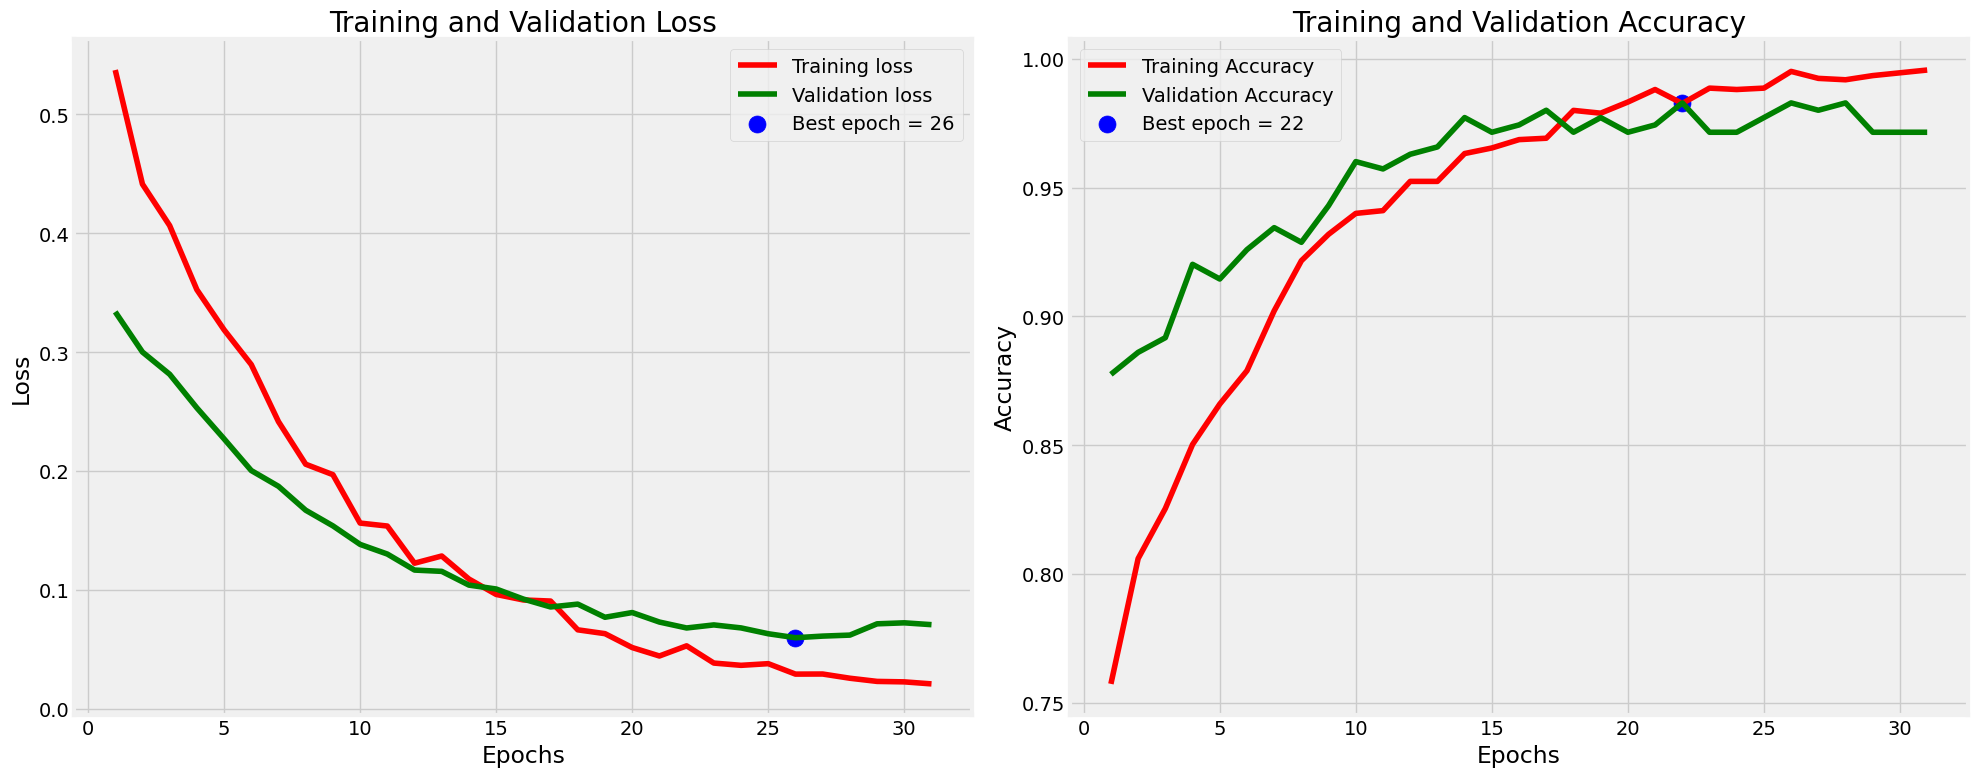

In [ ]:
plot_training(history_fine1)

In [ ]:
#FIND LAST LAYER
for layer in base_model1.layers[::-1]:
    if isinstance(layer, tf.keras.layers.Conv2D):
        print(layer.name)
        break


conv5_block16_2_conv


In [ ]:
def evaluate_with_gradcam(
    model,
    val_ds,
    last_conv_layer_name,
    model_name="Model",
    base_model_name=None,
    num_samples=5
):
    import numpy as np
    import matplotlib.pyplot as plt
    import cv2
    import tensorflow as tf

    # Evaluate model
    loss, acc, precision, recall, auc = model.evaluate(val_ds)
    print(f"\n📊 {model_name} Evaluation:")
    print(f"  Accuracy:  {acc * 100:.2f}%")
    print(f"  Precision: {precision * 100:.2f}%")
    print(f"  Recall:    {recall * 100:.2f}%")
    print(f"  AUC:       {auc * 100:.2f}%")

    # Get layers
    base_model = model.get_layer(base_model_name)
    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    # Get the path up to base_model
    inputs = model.input
    x = model.layers[1](inputs)             # data_augmentation
    x = model.layers[2](x)                  # preprocess_input

    # Create a new base model that outputs last conv layer + base output
    base_model_with_conv = tf.keras.Model(
        inputs=base_model.input,
        outputs=[last_conv_layer.output, base_model.output]
    )

    # Run base_model on x
    last_conv_output, base_output = base_model_with_conv(x)

    # Head
    x_head = model.layers[-5](base_output)  # GAP
    x_head = model.layers[-4](x_head)       # Dropout
    x_head = model.layers[-3](x_head)       # Dense
    x_head = model.layers[-2](x_head)       # Dropout
    output = model.layers[-1](x_head)

    # Final grad model
    grad_model = tf.keras.Model(
        inputs=inputs,
        outputs=[last_conv_output, output]
    )

    # Take a few samples
    val_batch = list(val_ds.unbatch().take(num_samples))

    for i, (img, label) in enumerate(val_batch):
        img_raw = img.numpy()  # [0–1]
        img_disp = (img_raw * 255).astype(np.uint8)

        img_exp = np.expand_dims(img_raw, axis=0)

        img_exp = tf.convert_to_tensor(img_exp, dtype=tf.float32)

        with tf.GradientTape() as tape:
            conv_outputs, predictions = grad_model(img_exp, training=False)
            pred_index = tf.argmax(predictions[0])
            class_channel = predictions[:, pred_index]

        grads = tape.gradient(class_channel, conv_outputs)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

        conv_outputs = conv_outputs[0]
        heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)

        heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
        heatmap_resized = cv2.resize(heatmap.numpy(), (img_disp.shape[1], img_disp.shape[0]))
        heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
        superimposed_img = cv2.addWeighted(img_disp, 0.6, heatmap_colored, 0.4, 0)

        pred = predictions.numpy()[0][0]

        plt.figure(figsize=(6, 6))
        plt.imshow(superimposed_img)
        plt.title(f"{model_name} Grad-CAM\nTrue: {int(label)} | Pred: {pred:.2f}")
        plt.axis('off')
        plt.show()


In [ ]:
# ==========INITIAL EVALUATION ==========
evaluate_with_gradcam(
    model1,
    val_ds,
    last_conv_layer_name="conv5_block16_2_conv",
    model_name="DenseNet121",
    base_model_name="densenet121"
)




11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step - accuracy: 0.9799 - auc: 0.9938 - loss: 0.0680 - precision: 0.9892 - recall: 0.9717

📊 DenseNet121 Evaluation:
  Accuracy:  98.29%
  Precision: 99.43%
  Recall:    97.22%
  AUC:       99.56%


ValueError: Input 0 of layer "functional_10" is incompatible with the layer: expected shape=(None, 224, 224, 3), found shape=(None, 7, 7, 1024)

In [ ]:
GPTBB

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall, AUC
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                        ReduceLROnPlateau, TensorBoard, Callback)
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
import cv2
import datetime
import os
import time

AUTOTUNE = tf.data.AUTOTUNE
EPOCHS = 20

# ========== DATASETS ==========


train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ========== AUGMENTATION ==========
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.05),
    tf.keras.layers.RandomContrast(0.05),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
])

# ========== MODEL ==========
preprocess_input = tf.keras.applications.densenet.preprocess_input
base_model1 = DenseNet121(include_top=False, weights='imagenet', input_shape=(224, 224, 3), name="densenet121")
base_model1.trainable = False

inputs1 = Input(shape=(224, 224, 3))
x = data_augmentation(inputs1)
x = preprocess_input(x)
x = base_model1(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs1 = Dense(1, activation='sigmoid')(x)
model1 = Model(inputs1, outputs1)

model1.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc')]
)

# ========== CALLBACKS ==========
class ValAccuracyImprovement(Callback):
    def __init__(self):
        super().__init__()
        self.best_val_accuracy = 0.0

    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get('val_accuracy', 0.0)
        if val_acc > self.best_val_accuracy:
            print(f"\n✅ Validation accuracy improved: {self.best_val_accuracy:.4f} → {val_acc:.4f}")
            self.best_val_accuracy = val_acc
        else:
            print(f"\nℹ️ Validation accuracy did not improve (Best: {self.best_val_accuracy:.4f})")

log_dir = os.path.join("logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
callbacks = [
    EarlyStopping(patience=5, monitor='val_loss', restore_best_weights=True),
    ModelCheckpoint('densenet121_stroke_best_model.h5', save_best_only=True, monitor='val_accuracy', mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6),
    TensorBoard(log_dir=log_dir),
    ValAccuracyImprovement()
]

# ========== TRAIN: Feature Extraction ==========
print("\n🚀 Starting feature extraction training …")
start_time = time.time()

history1 = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# ========== UNFREEZE & Fine-tune ==========
print("\n🔓 Unfreezing base model and fine-tuning …")
base_model1.trainable = True
for layer in base_model1.layers[:100]:
    layer.trainable = False

model1.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc')]
)

history_fine1 = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

print(f"\n⏱ Training completed in {(time.time() - start_time)/60:.2f} minutes")

# ========== EVALUATE & GRAD-CAM ==========
def evaluate_with_gradcam(model, val_ds, last_conv_layer_name, model_name="Model", base_model_name="densenet121", num_samples=5):
    print(f"\n🔍 Evaluating {model_name} …")
    loss, acc, precision, recall, auc = model.evaluate(val_ds)
    print(f"\n📊 {model_name} Evaluation:")
    print(f"  Accuracy:  {acc * 100:.2f}%")
    print(f"  Precision: {precision * 100:.2f}%")
    print(f"  Recall:    {recall * 100:.2f}%")
    print(f"  AUC:       {auc * 100:.2f}%")

    base_model = model.get_layer(base_model_name)
    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    inputs = model.input
    x = model.layers[1](inputs)
    x = model.layers[2](x)

    base_with_conv = tf.keras.Model(
        inputs=base_model.input,
        outputs=[last_conv_layer.output, base_model.output]
    )

    last_conv_output, base_output = base_with_conv(x)

    x_head = model.layers[-5](base_output)
    x_head = model.layers[-4](x_head)
    x_head = model.layers[-3](x_head)
    x_head = model.layers[-2](x_head)
    output = model.layers[-1](x_head)

    grad_model = tf.keras.Model(
        inputs=inputs,
        outputs=[last_conv_output, output]
    )

    val_batch = list(val_ds.unbatch().take(num_samples))

    for i, (img, label) in enumerate(val_batch):
        img_raw = img.numpy()
        img_disp = (img_raw * 255).astype(np.uint8)
        img_exp = np.expand_dims(img_raw, axis=0)

        img_exp = tf.convert_to_tensor(img_exp, dtype=tf.float32)

        with tf.GradientTape() as tape:
            conv_outputs, predictions = grad_model(img_exp, training=False)
            pred_index = tf.argmax(predictions[0])
            class_channel = predictions[:, pred_index]

        grads = tape.gradient(class_channel, conv_outputs)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

        conv_outputs = conv_outputs[0]
        heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)

        heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
        heatmap_resized = cv2.resize(heatmap.numpy(), (img_disp.shape[1], img_disp.shape[0]))
        heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
        superimposed_img = cv2.addWeighted(img_disp, 0.6, heatmap_colored, 0.4, 0)

        pred = predictions.numpy()[0][0]

        plt.figure(figsize=(6, 6))
        plt.imshow(superimposed_img)
        plt.title(f"{model_name} Grad-CAM\nTrue: {int(label)} | Pred: {pred:.2f}")
        plt.axis('off')
        plt.show()


# ========== RUN GRAD-CAM ==========
evaluate_with_gradcam(
    model1,
    val_ds,
    last_conv_layer_name="conv5_block16_2_conv",
    model_name="DenseNet121",
    base_model_name="densenet121"
)



🚀 Starting feature extraction training …
Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.5136 - auc: 0.4997 - loss: 0.9359 - precision: 0.5370 - recall: 0.5188


✅ Validation accuracy improved: 0.0000 → 0.6781
58/58 ━━━━━━━━━━━━━━━━━━━━ 48s 310ms/step - accuracy: 0.5139 - auc: 0.5004 - loss: 0.9344 - precision: 0.5372 - recall: 0.5199 - val_accuracy: 0.6781 - val_auc: 0.7497 - val_loss: 0.6033 - val_precision: 0.6754 - val_recall: 0.7167 - learning_rate: 1.0000e-04
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.6071 - auc: 0.6408 - loss: 0.7213 - precision: 0.6234 - recall: 0.6377


✅ Validation accuracy improved: 0.6781 → 0.7293
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 188ms/step - accuracy: 0.6072 - auc: 0.6410 - loss: 0.7212 - precision: 0.6234 - recall: 0.6379 - val_accuracy: 0.7293 - val_auc: 0.8302 - val_loss: 0.5365 - val_precision: 0.7179 - val_recall: 0.7778 - learning_rate: 1.0000e-04
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.6657 - auc: 0.7170 - loss: 0.6486 - precision: 0.6914 - recall: 0.6840


✅ Validation accuracy improved: 0.7293 → 0.7664
58/58 ━━━━━━━━━━━━━━━━━━━━ 12s 206ms/step - accuracy: 0.6655 - auc: 0.7169 - loss: 0.6488 - precision: 0.6910 - recall: 0.6839 - val_accuracy: 0.7664 - val_auc: 0.8606 - val_loss: 0.4991 - val_precision: 0.7552 - val_recall: 0.8056 - learning_rate: 1.0000e-04
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.6559 - auc: 0.7256 - loss: 0.6331 - precision: 0.6721 - recall: 0.6674


✅ Validation accuracy improved: 0.7664 → 0.7863
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 192ms/step - accuracy: 0.6561 - auc: 0.7258 - loss: 0.6329 - precision: 0.6723 - recall: 0.6676 - val_accuracy: 0.7863 - val_auc: 0.8753 - val_loss: 0.4801 - val_precision: 0.7665 - val_recall: 0.8389 - learning_rate: 1.0000e-04
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.7070 - auc: 0.7769 - loss: 0.5726 - precision: 0.7152 - recall: 0.7311

...


✅ Validation accuracy improved: 0.9544 → 0.9601
58/58 ━━━━━━━━━━━━━━━━━━━━ 40s 436ms/step - accuracy: 0.9322 - auc: 0.9790 - loss: 0.1859 - precision: 0.9492 - recall: 0.9202 - val_accuracy: 0.9601 - val_auc: 0.9892 - val_loss: 0.1377 - val_precision: 0.9511 - val_recall: 0.9722 - learning_rate: 1.0000e-05
Epoch 11/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.9437 - auc: 0.9856 - loss: 0.1541 - precision: 0.9611 - recall: 0.9318


✅ Validation accuracy improved: 0.9601 → 0.9658
58/58 ━━━━━━━━━━━━━━━━━━━━ 41s 439ms/step - accuracy: 0.9438 - auc: 0.9857 - loss: 0.1540 - precision: 0.9611 - recall: 0.9319 - val_accuracy: 0.9658 - val_auc: 0.9910 - val_loss: 0.1229 - val_precision: 0.9667 - val_recall: 0.9667 - learning_rate: 1.0000e-05
Epoch 12/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.9516 - auc: 0.9874 - loss: 0.1451 - precision: 0.9733 - recall: 0.9338


✅ Validation accuracy improved: 0.9658 → 0.9687
58/58 ━━━━━━━━━━━━━━━━━━━━ 25s 437ms/step - accuracy: 0.9517 - auc: 0.9875 - loss: 0.1449 - precision: 0.9733 - recall: 0.9341 - val_accuracy: 0.9687 - val_auc: 0.9913 - val_loss: 0.1144 - val_precision: 0.9721 - val_recall: 0.9667 - learning_rate: 1.0000e-05
Epoch 13/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.9636 - auc: 0.9929 - loss: 0.1076 - precision: 0.9758 - recall: 0.9542


✅ Validation accuracy improved: 0.9687 → 0.9744
58/58 ━━━━━━━━━━━━━━━━━━━━ 26s 455ms/step - accuracy: 0.9635 - auc: 0.9929 - loss: 0.1078 - precision: 0.9757 - recall: 0.9541 - val_accuracy: 0.9744 - val_auc: 0.9922 - val_loss: 0.1050 - val_precision: 0.9777 - val_recall: 0.9722 - learning_rate: 1.0000e-05
Epoch 14/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.9647 - auc: 0.9929 - loss: 0.1053 - precision: 0.9782 - recall: 0.9550
ℹ️ Validation accuracy did not improve (Best: 0.9744)
58/58 ━━━━━━━━━━━━━━━━━━━━ 24s 416ms/step - accuracy: 0.9647 - auc: 0.9929 - loss: 0.1052 - precision: 0.9782 - recall: 0.9551 - val_accuracy: 0.9715 - val_auc: 0.9929 - val_loss: 0.1010 - val_precision: 0.9830 - val_recall: 0.9611 - learning_rate: 1.0000e-05
Epoch 15/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.9725 - auc: 0.9936 - loss: 0.0977 - precision: 0.9736 - recall: 0.9723
ℹ️ Validation accuracy did not improve (Best: 0.9744)
58/58 ━━━━━━━━━━━━━━━━━━━━ 24s 420ms/step - acc

ValueError: Input 0 of layer "functional_13" is incompatible with the layer: expected shape=(None, 224, 224, 3), found shape=(None, 7, 7, 1024)


## RESNet 50 Model

In [ ]:

# Preprocessing
preprocess_input = tf.keras.applications.resnet.preprocess_input


In [ ]:

# Base model
base_model2 = ResNet50(include_top=False,
                      weights="imagenet",
                      input_shape=(224, 224, 3))

# Freeze base model
base_model2.trainable = False

# Build full model
inputs2 = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs2)
x = preprocess_input(x)
x = base_model2(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs2 = Dense(1, activation='sigmoid')(x)

model2 = Model(inputs2, outputs2)

# Compile model
model2.compile(optimizer=Adam(learning_rate=1e-4),
              loss="binary_crossentropy",
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc')])


# Custom Callback to track validation accuracy improvement
class ValAccuracyImprovement(Callback):
    def __init__(self):
        super().__init__()
        self.best_val_accuracy = 0.0

    def on_epoch_end(self, epoch, logs=None):
        current_val_accuracy = logs.get('val_accuracy', 0.0)

        if current_val_accuracy > self.best_val_accuracy:
            print(f"\n Validation accuracy improved from {self.best_val_accuracy:.4f} to {current_val_accuracy:.4f}")
            self.best_val_accuracy = current_val_accuracy
        else:
            print(f"\n Validation accuracy did not improve (Best: {self.best_val_accuracy:.4f}, Current: {current_val_accuracy:.4f})")

val_accuracy_cb2 = ValAccuracyImprovement()  # Custom callback

# Callbacks
log_dir = os.path.join("logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_cb = tf.keras.callbacks.TensorBoard(log_dir=log_dir)
checkpoint_cb = ModelCheckpoint("resnet50_stroke_best_model.h5",
                                monitor="val_accuracy",
                                save_best_only=True,
                                mode="max")
early_stopping_cb = EarlyStopping(monitor="val_loss",
                                  patience=5,
                                  restore_best_weights=True)
reduce_lr_cb = ReduceLROnPlateau(monitor='val_loss',
                                 factor=0.2,
                                 patience=3,
                                 min_lr=1e-6)

training_start_time2 = time.time()

# Train (feature extractor mode)
history2 = model2.fit(train_ds,
                    validation_data=val_ds,
                    epochs=EPOCHS,
                    callbacks=[checkpoint_cb, early_stopping_cb, reduce_lr_cb, tensorboard_cb, val_accuracy_cb2
])

# Fine-tune some layers of ResNet50
base_model2.trainable = True
fine_tune_at = 100  # Unfreeze last 50 layers
for layer in base_model2.layers[:fine_tune_at]:
    layer.trainable = False

# Recompile for fine-tuning
model2.compile(optimizer=Adam(learning_rate=1e-5),
              loss="binary_crossentropy",
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc')])

# Fine-tuning
history_fine2 = model2.fit(train_ds,
                         validation_data=val_ds,
                         epochs=EPOCHS,
                         callbacks=[checkpoint_cb, early_stopping_cb, reduce_lr_cb, tensorboard_cb, val_accuracy_cb2])
training_end_time2 = time.time()


In [ ]:
plot_training(history_fine2)


In [ ]:
# ==========INITIAL EVALUATION ==========
evaluate_with_gradcam(model2, val_ds, "conv5_block3_out", "ResNet50")


## Xception Model

In [ ]:
# === Xception preprocessing ===
preprocess_input = tf.keras.applications.xception.preprocess_input


In [ ]:
# Parameters
IMG_SIZE = (299, 299)
BATCH_SIZE = 32
EPOCHS = 50
AUTOTUNE = tf.data.AUTOTUNE

# Load datasets
train_ds = image_dataset_from_directory(train_dir,
                                        image_size=IMG_SIZE,
                                        batch_size=BATCH_SIZE,
                                        label_mode="binary")

val_ds = image_dataset_from_directory(val_dir,
                                      image_size=IMG_SIZE,
                                      batch_size=BATCH_SIZE,
                                      label_mode="binary")

test_ds = image_dataset_from_directory(test_dir,
                                       image_size=IMG_SIZE,
                                       batch_size=BATCH_SIZE,
                                       label_mode="binary")

# === Load Xception base model ===

base_model3 = Xception(include_top=False,
                      weights='imagenet',
                      input_shape=(299, 299, 3))
base_model3.trainable = False  # freeze for transfer learning

# === Build model ===
inputs3 = Input(shape=(299, 299, 3))  # Xception expects 299x299

# Move data augmentation directly into the model
x = tf.keras.layers.RandomFlip("horizontal")(inputs3)
x = tf.keras.layers.RandomRotation(0.1)(x)
x = tf.keras.layers.RandomZoom(0.1)(x)
x = tf.keras.layers.RandomContrast(0.1)(x)

x = preprocess_input(x)
x = base_model3(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs3 = Dense(1, activation='sigmoid')(x)

model3 = Model(inputs3, outputs3)


# === Compile ===
model3.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc')])
# Custom Callback to track validation accuracy improvement
class ValAccuracyImprovement(Callback):
    def __init__(self):
        super().__init__()
        self.best_val_accuracy = 0.0

    def on_epoch_end(self, epoch, logs=None):
        current_val_accuracy = logs.get('val_accuracy', 0.0)

        if current_val_accuracy > self.best_val_accuracy:
            print(f"\n🔥 Validation accuracy improved from {self.best_val_accuracy:.4f} to {current_val_accuracy:.4f}")
            self.best_val_accuracy = current_val_accuracy
        else:
            print(f"\n❌ Validation accuracy did not improve (Best: {self.best_val_accuracy:.4f}, Current: {current_val_accuracy:.4f})")

val_accuracy_cb3 = ValAccuracyImprovement()  # Custom callback

# === Callbacks ===
log_dir = os.path.join("logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('xception_stroke_best_model.h5', monitor='val_accuracy', save_best_only=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6),
    TensorBoard(log_dir=log_dir),
    val_accuracy_cb3
]
training_start_time3 = time.time()

history = model3.fit(train_ds,
                    validation_data=val_ds,
                    epochs=EPOCHS,
                    callbacks=callbacks)

# === Phase 2: Fine-tuning ===
base_model3.trainable = True
fine_tune_at = 100  # Freeze early layers

for layer in base_model3.layers[:fine_tune_at]:
    layer.trainable = False

# Re-compile with lower LR
model3.compile(optimizer=Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc')])

# Fine-tune training
history_fine3 = model3.fit(train_ds,
                         validation_data=val_ds,
                         epochs=EPOCHS,
                         callbacks=callbacks)
training_end_time3 = time.time()

In [ ]:
plot_training(history_fine3)


In [ ]:
# ==========INITIAL EVALUATION ==========
evaluate_with_gradcam(model3, val_ds, "block14_sepconv2", "Xception")


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:5px; color:white; margin:0; font-size:100%; font-family:Pacifico; background-color:#28a745; overflow:hidden"><b> Evaluate Models ✅ </b></div>

## DenseNet

In [ ]:
# ========== FINAL EVALUATION ==========
loss, acc, precision, recall, auc = model1.evaluate(test_ds)
print(f"Test Accuracy: {acc * 100:.2f}%")
print(f"Test Precision: {precision * 100:.2f}%")
print(f"Test Recall: {recall * 100:.2f}%")
print(f"Test AUC: {auc * 100:.2f}%")

In [ ]:
test_ds_224 = image_dataset_from_directory(test_dir,
                                           image_size=(224, 224),
                                           batch_size=BATCH_SIZE,
                                           label_mode="binary")


# === EVALUATION ON TEST SET ===
y_true = []
y_pred = []

for images, labels in test_ds_224:
    preds = model1.predict(images)
    y_pred.extend((preds > 0.5).astype("int32").flatten())
    y_true.extend(labels.numpy().astype("int32").flatten())

# Metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["No Stroke", "Stroke"]))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plot_confusion_matrix(cm, classes=["No Stroke", "Stroke"], title='Confusion Matrix')

# Basic computational efficiency (training time)
print(f"Training started at: {training_start_time1}")
print(f"Training ended at: {training_end_time1}")
print(f"Total training duration: {training_end_time1 - training_start_time1:.2f} seconds")


## ResNet50

In [ ]:
# ========== FINAL EVALUATION ==========
loss, acc, precision, recall, auc = model2.evaluate(test_ds)
print(f"Test Accuracy: {acc * 100:.2f}%")
print(f"Test Precision: {precision * 100:.2f}%")
print(f"Test Recall: {recall * 100:.2f}%")
print(f"Test AUC: {auc * 100:.2f}%")

In [ ]:
# === EVALUATION ON TEST SET ===
y_true = []
y_pred = []

for images, labels in test_ds_224:
    preds = model2.predict(images)
    y_pred.extend((preds > 0.5).astype("int32").flatten())
    y_true.extend(labels.numpy().astype("int32").flatten())

# Metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["No Stroke", "Stroke"]))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plot_confusion_matrix(cm, classes=["No Stroke", "Stroke"], title='Confusion Matrix')

# Basic computational efficiency (training time)
print(f"Training started at: {training_start_time2}")
print(f"Training ended at: {training_end_time2}")
print(f"Total training duration: {training_end_time2 - training_start_time2:.2f} seconds")


## Xception

In [ ]:
# ========== FINAL EVALUATION ==========
loss, acc, precision, recall, auc = model3.evaluate(test_ds)
print(f"Test Accuracy: {acc * 100:.2f}%")
print(f"Test Precision: {precision * 100:.2f}%")
print(f"Test Recall: {recall * 100:.2f}%")
print(f"Test AUC: {auc * 100:.2f}%")

In [ ]:
# === EVALUATION ON TEST SET ===
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model3.predict(images)
    y_pred.extend((preds > 0.5).astype("int32").flatten())
    y_true.extend(labels.numpy().astype("int32").flatten())

# Metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["No Stroke", "Stroke"]))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plot_confusion_matrix(cm, classes=["No Stroke", "Stroke"], title='Confusion Matrix')

# Basic computational efficiency (training time)
print(f"Training started at: {training_start_time3}")
print(f"Training ended at: {training_end_time3}")
print(f"Total training duration: {training_end_time3 - training_start_time3:.2f} seconds")


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:5px; color:white; margin:0; font-size:100%; font-family:Pacifico; background-color:#28a745; overflow:hidden"><b> Save Models ✅ </b></div>

In [ ]:
model1.save('DenseNet121.keras')
model3.save("Xception.keras")
model2.save("ResNet50.keras")
model1.save('/content/drive/MyDrive/DenseNet121.keras')
model2.save('/content/drive/MyDrive/ResNet50.keras')
model3.save('/content/drive/MyDrive/Xception.keras')


In [ ]:
results = {
    "DenseNet121": {"Accuracy": acc1, "Precision": precision1, "Recall": recall1, "AUC": auc1},
    "ResNet50": {"Accuracy": acc2, "Precision": precision2, "Recall": recall2, "AUC": auc2},
    "Xception": {"Accuracy": acc3, "Precision": precision3, "Recall": recall3, "AUC": auc3}
}


In [ ]:

def plot_model_comparison(results):
    labels = list(results.keys())
    accuracy = [results[m]["Accuracy"] for m in labels]
    precision = [results[m]["Precision"] for m in labels]
    recall = [results[m]["Recall"] for m in labels]
    auc = [results[m]["AUC"] for m in labels]

    x = range(len(labels))
    width = 0.2

    plt.figure(figsize=(10, 6))
    plt.bar([p - 1.5*width for p in x], accuracy, width=width, label="Accuracy")
    plt.bar([p - 0.5*width for p in x], precision, width=width, label="Precision")
    plt.bar([p + 0.5*width for p in x], recall, width=width, label="Recall")
    plt.bar([p + 1.5*width for p in x], auc, width=width, label="AUC")

    plt.xticks(x, labels)
    plt.ylabel("Score")
    plt.title("Model Performance Comparison")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_model_line_chart(results):
    metrics = ["Accuracy", "Precision", "Recall", "AUC"]
    models = list(results.keys())

    plt.figure(figsize=(10, 6))

    for model in models:
        values = [results[model][metric] for metric in metrics]
        plt.plot(metrics, values, marker='o', label=model)

    plt.ylabel("Score")
    plt.title("Model Metric Comparison")
    plt.legend()
    plt.grid(True)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()


In [ ]:

def plot_model_radar_chart(results):
    labels = list(results.keys())
    metrics = ["Accuracy", "Precision", "Recall", "AUC"]
    num_metrics = len(metrics)

    angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
    angles += angles[:1]  # Complete the loop

    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)

    for model in labels:
        values = [results[model][metric] for metric in metrics]
        values += values[:1]
        ax.plot(angles, values, label=model)
        ax.fill(angles, values, alpha=0.1)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), metrics)
    ax.set_ylim(0, 1)
    plt.title("Model Performance Radar Chart", y=1.08)
    plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()


In [ ]:
plot_model_comparison(results)


In [ ]:
plot_model_line_chart(results)

In [ ]:
plot_model_radar_chart(results)

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:5px; color:white; margin:0; font-size:100%; font-family:Pacifico; background-color:#28a745; overflow:hidden"><b> Make Prediction 🎯 </b></div>